# Extract Distributions from Olist Seed

In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt

SEED_DIR = "../data/seed"
LOOKUP_DIR = "../data/lookup"
os.makedirs(LOOKUP_DIR, exist_ok=True)

In [8]:
BAR_COLOR = "#2a78d6"
GRID_COLOR = "#e1e0d9"
AXIS_COLOR = "#898781"
TEXT_COLOR = "#0b0b0b"


def plot_bar(labels, values, title, value_fmt="{:.1%}"):
    labels = list(labels)
    values = list(values)
    fig, ax = plt.subplots(figsize=(7, 0.45 * len(labels) + 1))
    y_pos = range(len(labels))
    ax.barh(y_pos, values, color=BAR_COLOR)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, color=TEXT_COLOR)
    ax.invert_yaxis()
    ax.set_title(title, color=TEXT_COLOR, fontsize=12, loc="left")
    ax.xaxis.grid(True, color=GRID_COLOR, linewidth=1)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(AXIS_COLOR)
    ax.tick_params(colors=AXIS_COLOR)
    for y, v in zip(y_pos, values):
        ax.text(v, y, " " + value_fmt.format(v), va="center", color=TEXT_COLOR, fontsize=9)
    plt.tight_layout()
    plt.show()

In [9]:
order_items = pd.read_csv(f"{SEED_DIR}/olist_order_items_dataset.csv")
products = pd.read_csv(f"{SEED_DIR}/olist_products_dataset.csv")
payments = pd.read_csv(f"{SEED_DIR}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{SEED_DIR}/olist_order_reviews_dataset.csv")
orders = pd.read_csv(f"{SEED_DIR}/olist_orders_dataset.csv")

## Average price / standard deviation by category

In [10]:
items_with_category = order_items.merge(
    products[["product_id", "product_category_name"]], on="product_id", how="left"
)

category_price_stats = (
    items_with_category.groupby("product_category_name")["price"]
    .agg(avg_price="mean", stddev_price="std")
    .reset_index()
)

category_price_stats.to_csv(f"{LOOKUP_DIR}/category_price_stats.csv", index=False)
category_price_stats.head()

,product_category_name,avg_price,stddev_price
0,agro_industria_e_comercio,342.124858,419.429802
1,alimentos,57.634137,41.337421
2,alimentos_bebidas,54.602446,68.717537
3,artes,115.802105,445.661765
4,artes_e_artesanato,75.583750,73.997815


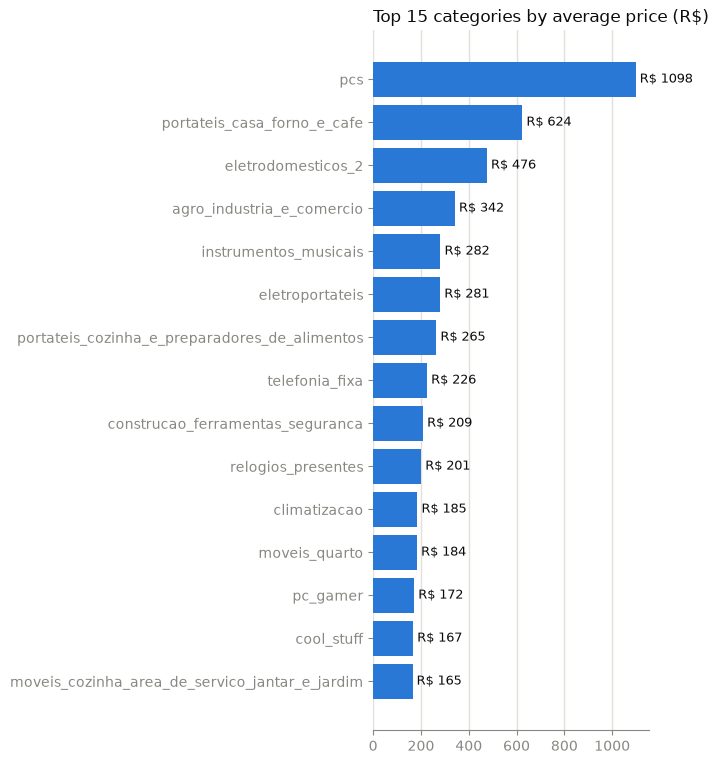

In [11]:
top_categories = (
    category_price_stats.dropna(subset=["product_category_name"])
    .sort_values("avg_price", ascending=False)
    .head(15)
)
plot_bar(
    top_categories["product_category_name"],
    top_categories["avg_price"],
    "Top 15 categories by average price (R$)",
    value_fmt="R$ {:.0f}",
)

## Payment type distribution

In [12]:
payment_type_distribution = payments["payment_type"].value_counts(normalize=True).reset_index()
payment_type_distribution.columns = ["payment_type", "pct"]

payment_type_distribution.to_csv(f"{LOOKUP_DIR}/payment_type_distribution.csv", index=False)
payment_type_distribution

,payment_type,pct
0,credit_card,0.739224
1,boleto,0.190440
2,voucher,0.055590
3,debit_card,0.014718
4,not_defined,0.000029


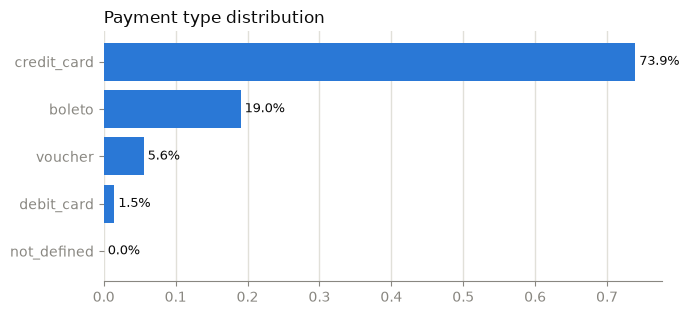

In [13]:
pt = payment_type_distribution.sort_values("pct", ascending=False)
plot_bar(pt["payment_type"], pt["pct"], "Payment type distribution")

## Review score distribution

In [14]:
review_score_distribution = reviews["review_score"].value_counts(normalize=True).reset_index()
review_score_distribution.columns = ["review_score", "pct"]

review_score_distribution.to_csv(f"{LOOKUP_DIR}/review_score_distribution.csv", index=False)
review_score_distribution

,review_score,pct
0,5,0.577763
1,4,0.192917
2,1,0.115133
3,3,0.082430
4,2,0.031756


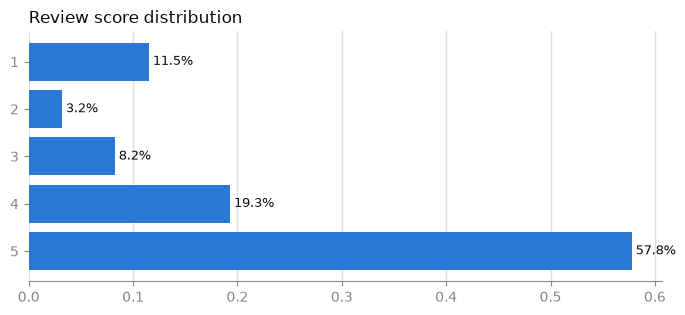

In [9]:
rs = review_score_distribution.sort_values("review_score")
plot_bar(rs["review_score"].astype(str), rs["pct"], "Review score distribution")

## Order status distribution

In [10]:
order_status_distribution = orders["order_status"].value_counts(normalize=True).reset_index()
order_status_distribution.columns = ["order_status", "pct"]

order_status_distribution.to_csv(f"{LOOKUP_DIR}/order_status_distribution.csv", index=False)
order_status_distribution

,order_status,pct
0,delivered,0.970203
1,shipped,0.011132
2,canceled,0.006285
3,unavailable,0.006124
4,invoiced,0.003158
5,processing,0.003027
6,created,0.000050
7,approved,0.000020


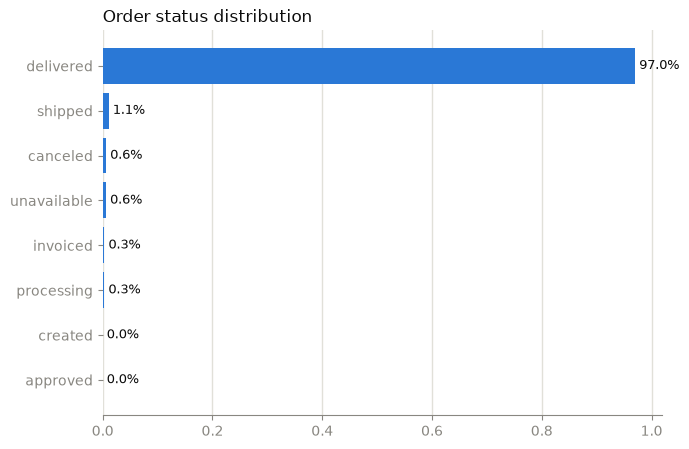

In [11]:
os_dist = order_status_distribution.sort_values("pct", ascending=False)
plot_bar(os_dist["order_status"], os_dist["pct"], "Order status distribution")